# Visualize composite sensor processing

Load a composite sensor-processing graph from an exp/run, then visualize its ordered steps, references, and output. Model checkpoints and registered operation implementations are not required.

In [1]:
import pathlib
import pprint
import sys

sys.path.append("..")

from exp_run_config import Config
Config.PROJECTNAME = "BerryPicker"

from graphviz import Digraph
from IPython.display import display

## Exp/run selection

The default selection is the illustrative composite from `DESIGN-CompositeSensorProcessing.md`. Select an existing internal run or provide an external exprun directory containing the generated composite run.

In [2]:
creation_style = "exist-ok"
expruns_path = None
results_path = None

experiment = "sensorprocessing_composite"
run = "appearance_foreground_256"

In [3]:
if expruns_path:
    expruns_path = pathlib.Path(expruns_path)
    if not expruns_path.exists():
        raise FileNotFoundError(expruns_path)
    Config().set_exprun_path(expruns_path)

if results_path:
    results_path = pathlib.Path(results_path)
    if not results_path.exists():
        raise FileNotFoundError(results_path)
    Config().set_results_path(results_path)

exp = Config().get_experiment(
    experiment, run, creation_style=creation_style
)
summary = {
    key: exp[key]
    for key in ("class", "image_size", "latent_size", "output")
}
for key in ("num_views", "cameras", "sample_interval"):
    if key in exp:
        summary[key] = exp[key]
pprint.pp(summary)

***ExpRun**: Loading pointer config file:
	/Users/lboloni/.config/BerryPicker/mainsettings.yaml
***ExpRun**: Loading machine-specific config file:
	/Users/lboloni/Google Drive/My Drive/LotziStudy/Code/PackageTracking/BerryPicker/settings/settings-szenes.yaml
***ExpRun**: Using torch device: cpu
***ExpRun**: Configuration for exp/run: sensorprocessing_composite/appearance_foreground_256 successfully loaded
{'class': 'CompositeSensorProcessing',
 'image_size': [256, 256],
 'latent_size': 256,
 'output': 'combined'}


## Step summary

In [4]:
step_rows = []
for step in exp["steps"]:
    row = {
        "name": step["name"],
        "operation": step["operation"],
        "inputs": step["inputs"],
        "frozen": step.get("frozen", False),
    }
    if "source_experiment" in step:
        row["source exp/run"] = (
            f"{step['source_experiment']}/{step['source_run']}"
        )
    step_rows.append(row)
pprint.pp(step_rows)

[{'name': 'filtered',
  'operation': 'gaussian_blur',
  'inputs': ['input'],
  'frozen': False},
 {'name': 'probabilities',
  'operation': 'segmentation',
  'inputs': ['filtered'],
  'frozen': True,
  'source exp/run': 'sensorprocessing_segmentation/foreground_model'},
 {'name': 'mask',
  'operation': 'select_class',
  'inputs': ['probabilities'],
  'frozen': False},
 {'name': 'foreground',
  'operation': 'apply_mask',
  'inputs': ['filtered', 'mask'],
  'frozen': False},
 {'name': 'appearance',
  'operation': 'encoder',
  'inputs': ['filtered'],
  'frozen': True,
  'source exp/run': 'sensorprocessing_conv_vae_neo/sp_vae_neo_128_256px_dev2_dev3'},
 {'name': 'foreground_features',
  'operation': 'encoder',
  'inputs': ['foreground'],
  'frozen': True,
  'source exp/run': 'sensorprocessing_conv_vae_neo/sp_vae_neo_128_256px_dev2_dev3'},
 {'name': 'combined',
  'operation': 'concat',
  'inputs': ['appearance', 'foreground_features'],
  'frozen': False}]


## Graph visualization

Gray nodes are external input and output, blue steps are composite-owned or parameter-free, and pale gray steps are frozen. Dotted field references are shown on their edges.

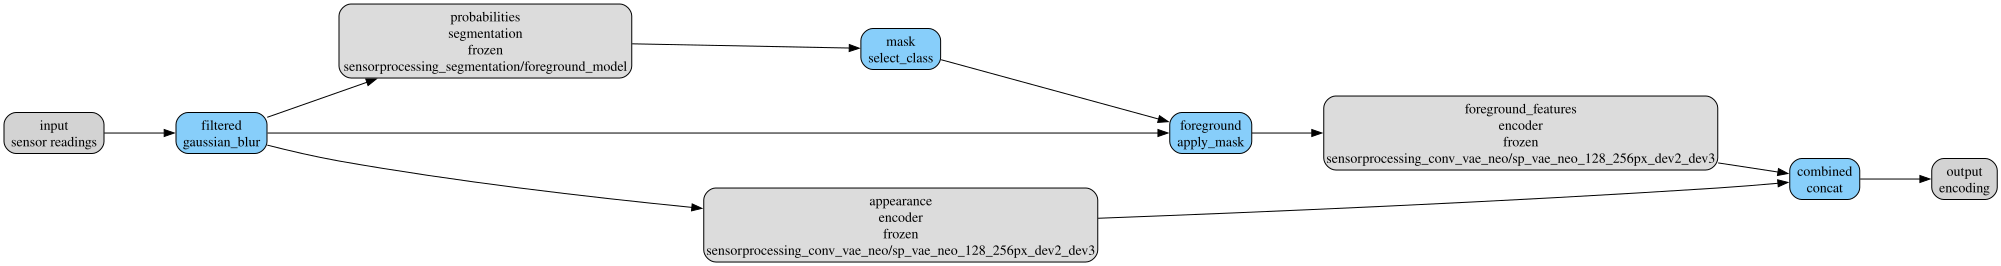

In [5]:
def step_label(step):
    details = [step["name"], step["operation"]]
    if step.get("frozen", False):
        details.append("frozen")
    if "source_experiment" in step:
        details.append(
            f"{step['source_experiment']}/{step['source_run']}"
        )
    return "\n".join(details)


def reference_parts(reference):
    parts = reference.split(".", 1)
    producer = "__input__" if parts[0] == "input" else parts[0]
    field = parts[1] if len(parts) == 2 else ""
    return producer, field


def build_composite_graph(exp):
    dot = Digraph(comment=f"{experiment}/{run}")
    dot.attr(rankdir="LR", nodesep="0.5", ranksep="1.0")
    dot.attr("node", shape="box", style="filled,rounded")
    dot.node("__input__", "input\nsensor readings", fillcolor="lightgray")

    for step in exp["steps"]:
        color = "gainsboro" if step.get("frozen", False) else "lightskyblue"
        dot.node(step["name"], step_label(step), fillcolor=color)
        for reference in step["inputs"]:
            producer, field = reference_parts(reference)
            dot.edge(producer, step["name"], label=field)

    output_producer, output_field = reference_parts(exp["output"])
    dot.node("__output__", "output\nencoding", fillcolor="lightgray")
    dot.edge(output_producer, "__output__", label=output_field)
    return dot


display(build_composite_graph(exp))